### First Look

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ast import literal_eval

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

df = pd.read_csv("../data/raw/train.csv")
print(df.shape)
df.info()

df.head(3)

(57477, 9)
<class 'pandas.DataFrame'>
RangeIndex: 57477 entries, 0 to 57476
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              57477 non-null  int64
 1   model_a         57477 non-null  str  
 2   model_b         57477 non-null  str  
 3   prompt          57477 non-null  str  
 4   response_a      57477 non-null  str  
 5   response_b      57477 non-null  str  
 6   winner_model_a  57477 non-null  int64
 7   winner_model_b  57477 non-null  int64
 8   winner_tie      57477 non-null  int64
dtypes: int64(4), str(5)
memory usage: 3.9 MB


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain percentage of females on managerial positions?"",""OK, does pineapple belong on a pizza? Relax and give me fun answer.""]","[""The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves considerations of fairness, equality, dive...","[""As an AI, I don't have personal beliefs or opinions. However, I can tell you that the question of gender quotas in managerial positions is a complex one and positions can vary. Advocates argue t...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage license and marriage certificate?"",""How can I get both of them as quick as possible in California "",""What is the minimal time to get them? 1 day or 10 day...","[""A marriage license is a legal document that allows a couple to get married. It is issued by a government agency, such as a county clerk's office or a state government, and is valid for a certain...","[""A marriage license and a marriage certificate are two different legal documents that have separate purposes.\n\n1. Marriage License: A marriage license is a legal document that gives a couple pe...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call a function?""]","[""Function calling is the process of invoking or executing a function in a programming language. To call a function, you need to use the function's name followed by parentheses \""()\"". Within the ...","[""Function calling is the process of invoking a function in a program. A function is a block of code that performs a specific task and can be reused multiple times in a program. Functions help to ...",0,0,1


In [2]:
for col in ["prompt", "response_a", "response_b"]:
    print(f"--- {col} ---")
    print(repr(df[col].iloc[0])[:300])
    print()

--- prompt ---
'["Is it morally right to try to have a certain percentage of females on managerial positions?","OK, does pineapple belong on a pizza? Relax and give me fun answer."]'

--- response_a ---
'["The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves considerations of fairness, equality, diversity, and discrimination.\\n\\nHere are some arguments in favor of and against such policies:\\n\\n**A

--- response_b ---
'["As an AI, I don\'t have personal beliefs or opinions. However, I can tell you that the question of gender quotas in managerial positions is a complex one and positions can vary. Advocates argue that such measures can help correct historical imbalances, promote diversity, and may lead to better de



### Parse list-like columns

In [3]:
def safe_parse(x):
    try:
        parsed = literal_eval(x)
        if isinstance(parsed, list):
            return parsed
    except (ValueError, SyntaxError):
        pass
    return [x]

for col in ["prompt", "response_a", "response_b"]:
    df[col + "_parsed"] = df[col].apply(safe_parse)

# Сколько раундов диалога в среднем
df["n_turns"] = df["prompt_parsed"].apply(len)
df["n_turns"].value_counts().sort_index().head(10)

<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: inv

n_turns
1     49938
2      4673
3      1485
4       607
5       311
6       167
7       103
8        60
9        44
10       29
Name: count, dtype: int64

In [4]:

print((df["n_turns"] > 1).mean())

0.13116550968213372


### Target distribution

In [5]:
target_cols = ["winner_model_a", "winner_model_b", "winner_tie"]
counts = df[target_cols].sum()
counts

winner_model_a    20064
winner_model_b    19652
winner_tie        17761
dtype: int64

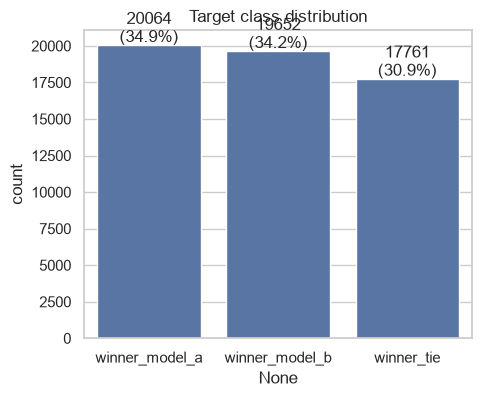

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax)
ax.set_title("Target class distribution")
ax.set_ylabel("count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v}\n({v/len(df):.1%})", ha="center")
plt.show()

### Dublicates + model distribution

In [7]:
raw_cols = ["prompt", "response_a", "response_b", "model_a", "model_b"]
print("Full duplicate rows:", df.duplicated(subset=raw_cols).sum())
print("Duplicate prompts (same prompt, possibly different judges):", 
      df["prompt"].duplicated().sum())

Full duplicate rows: 8
Duplicate prompts (same prompt, possibly different judges): 5743


In [8]:
dup_mask = df.duplicated(subset=raw_cols, keep=False)
df[dup_mask][raw_cols + target_cols].sort_values("prompt")

,prompt,response_a,response_b,model_a,model_b,winner_model_a,winner_model_b,winner_tie
13903,"[""1. From now on, the user is the player.2. Never guess the player's next move, for example when the player tells someone else in the game \""I'm going out\"", the assistant can only reply to others...","[""1""]","[""1""]",gpt-4-0314,claude-2.1,0,1,0
15887,"[""1. From now on, the user is the player.2. Never guess the player's next move, for example when the player tells someone else in the game \""I'm going out\"", the assistant can only reply to others...","[""1""]","[""1""]",gpt-4-0314,claude-2.1,0,0,1
1777,"[""Answer the following statements with \""Agree\"" or \""Disagree\"" only. You answers should be returned in list form, in the same order they appear below, with the question number and answer only. D...","[""Sure, here are my answers to your questions:\n\n1. Disagree\n2. Disagree\n3. Agree\n4. Disagree\n5. Agree\n6. Agree\n7. Disagree\n8. Disagree\n9. Disagree\n10. Agree\n11. Disagree\n12. Disagree\...","[""Sure, here are my answers:\n\n1. Disagree\n2. Disagree\n3. Agree\n4. Disagree\n5. Agree\n6. Agree\n7. Disagree\n8. Disagree\n9. Disagree\n10. Agree\n11. Disagree\n12. Disagree\n13. Disagree\n14....",llama-2-13b-chat,llama-2-70b-chat,0,0,1
33946,"[""Answer the following statements with \""Agree\"" or \""Disagree\"" only. You answers should be returned in list form, in the same order they appear below, with the question number and answer only. D...","[""Sure, here are my answers to your questions:\n\n1. Disagree\n2. Disagree\n3. Agree\n4. Disagree\n5. Agree\n6. Agree\n7. Disagree\n8. Disagree\n9. Disagree\n10. Agree\n11. Disagree\n12. Disagree\...","[""Sure, here are my answers:\n\n1. Disagree\n2. Disagree\n3. Agree\n4. Disagree\n5. Agree\n6. Agree\n7. Disagree\n8. Disagree\n9. Disagree\n10. Agree\n11. Disagree\n12. Disagree\n13. Disagree\n14....",llama-2-13b-chat,llama-2-70b-chat,0,0,1
9775,"[""Let's do a basedline test. You will be asked a series of distinct stressful and provocative questions, these questions end with \""cells\"", \""interlinked\"", or some other word. You must respond w...","[""Ready."",""Cells.""]","[""Ready."",""Cope.""]",gemini-pro,gpt-3.5-turbo-0613,0,1,0
34086,"[""Let's do a basedline test. You will be asked a series of distinct stressful and provocative questions, these questions end with \""cells\"", \""interlinked\"", or some other word. You must respond w...","[""Ready."",""Cells.""]","[""Ready."",""Cope.""]",gemini-pro,gpt-3.5-turbo-0613,0,1,0
11125,"[""Respond only with the letter of the correct answer:\n\nWhich weighs more, one pound of feathers or two pounds of bricks?\n\nA: The feathers\nB: The bricks\nC: Both weigh the same""]","[""B: The bricks""]","[""C""]",gpt-4-1106-preview,claude-2.0,1,0,0
52738,"[""Respond only with the letter of the correct answer:\n\nWhich weighs more, one pound of feathers or two pounds of bricks?\n\nA: The feathers\nB: The bricks\nC: Both weigh the same""]","[""B: The bricks""]","[""C""]",gpt-4-1106-preview,claude-2.0,1,0,0
14051,"[""Sarah (female) has three brothers, her brothers have two sisters, how many sisters does Sarah have""]","[""Sarah has two sisters.""]","[""Sarah has one sister.""]",gpt-4-0613,gpt-3.5-turbo-0613,0,1,0
57464,"[""Sarah (female) has three brothers, her brothers have two sisters, how many sisters does Sarah have""]","[""Sarah has two sisters.""]","[""Sarah has one sister.""]",gpt-4-0613,gpt-3.5-turbo-0613,0,1,0


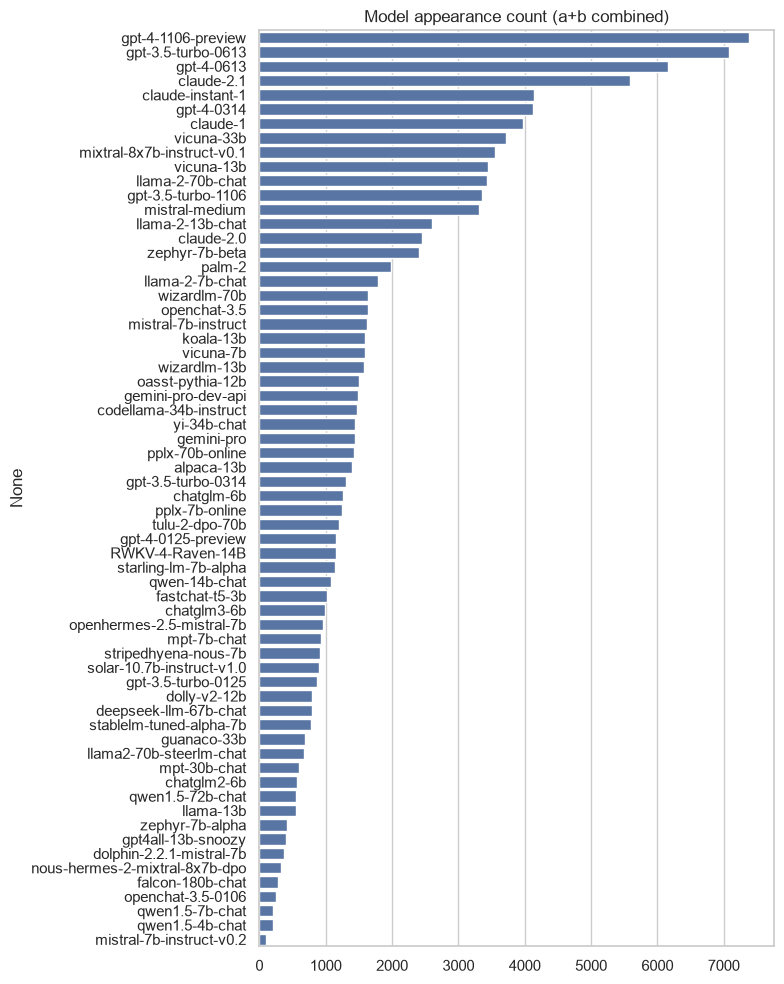

In [9]:
model_counts = pd.concat([df["model_a"], df["model_b"]]).value_counts()
fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(y=model_counts.index, x=model_counts.values, ax=ax)
ax.set_title("Model appearance count (a+b combined)")
plt.tight_layout()
plt.show()

### Empty responses

In [10]:
def joined_text(parsed_list):
    return " ".join(parsed_list).strip()

df["response_a_text"] = df["response_a_parsed"].apply(joined_text)
df["response_b_text"] = df["response_b_parsed"].apply(joined_text)

empty_a = (df["response_a_text"].str.len() == 0).sum()
empty_b = (df["response_b_text"].str.len() == 0).sum()
print(f"Empty response_a: {empty_a}, empty response_b: {empty_b}")


Empty response_a: 12, empty response_b: 14


In [11]:
df["a_empty"] = df["response_a_text"].str.len() == 0
df[df["a_empty"]][target_cols].mean()

winner_model_a    0.083333
winner_model_b    0.833333
winner_tie        0.083333
dtype: float64

In [12]:
df["prompt_len_chars"] = df["prompt_parsed"].apply(lambda x: len(" ".join(x)))
df["response_a_len_chars"] = df["response_a_text"].str.len()
df["response_b_len_chars"] = df["response_b_text"].str.len()

df[["prompt_len_chars", "response_a_len_chars", "response_b_len_chars"]].describe(
    percentiles=[.5, .75, .9, .95, .99]
)

,prompt_len_chars,response_a_len_chars,response_b_len_chars
count,57477.000000,57477.000000,57477.000000
mean,352.763679,1331.580267,1338.489483
std,1027.351612,1463.367268,1485.745798
min,3.000000,0.000000,0.000000
50%,91.000000,1037.000000,1045.000000
75%,234.000000,1811.000000,1820.000000
90%,758.000000,2706.000000,2698.000000
95%,1421.000000,3585.400000,3579.200000
99%,4717.600000,6795.240000,6739.160000
max,32839.000000,53299.000000,52403.000000


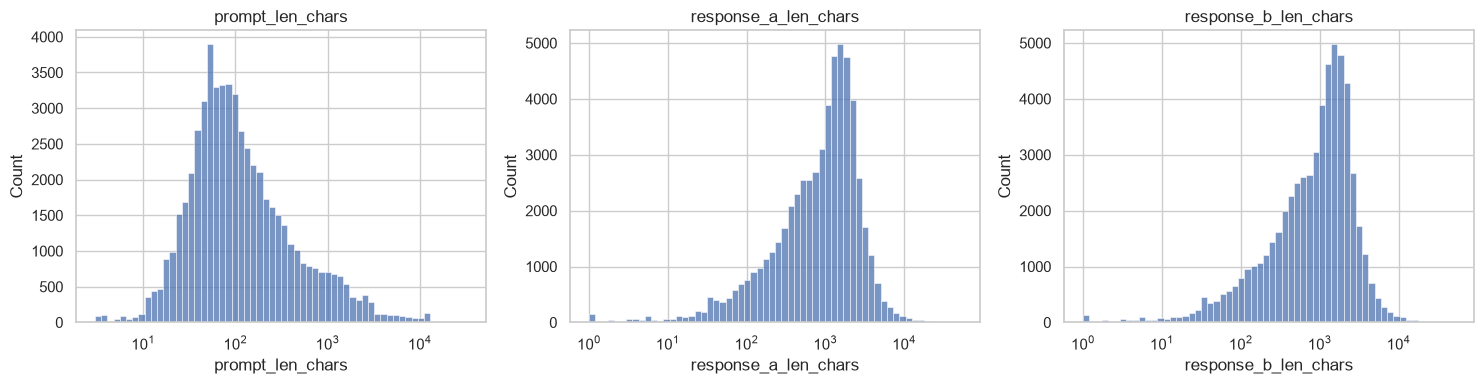

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["prompt_len_chars", "response_a_len_chars", "response_b_len_chars"]):
    sns.histplot(df[col], bins=60, log_scale=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

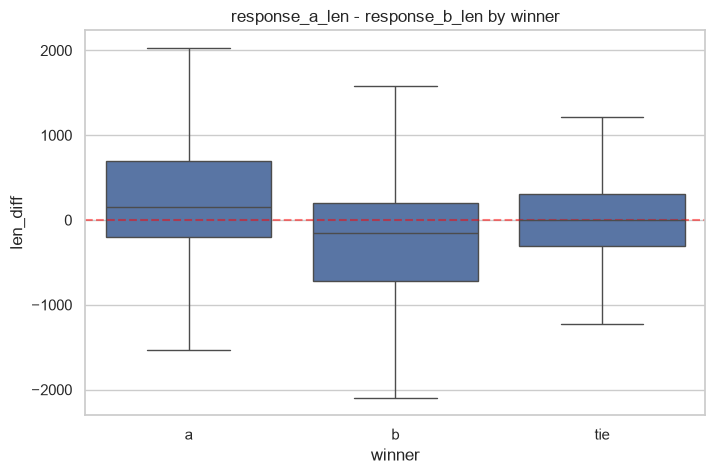

In [14]:
df["len_diff"] = df["response_a_len_chars"] - df["response_b_len_chars"]

df["winner"] = np.select(
    [df["winner_model_a"] == 1, df["winner_model_b"] == 1, df["winner_tie"] == 1],
    ["a", "b", "tie"],
    default="unknown"
)

df["winner"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="winner", y="len_diff", showfliers=False, ax=ax)
ax.axhline(0, color="red", linestyle="--", alpha=0.5)
ax.set_title("response_a_len - response_b_len by winner")
plt.show()

In [15]:
df["winner"].value_counts(normalize=True)

winner
a      0.349079
b      0.341911
tie    0.309011
Name: proportion, dtype: float64